# A Virtual GPU: Watch a Tesla T4 Execute Your Kernel

The [SIMT simulator](01b_simt_simulator.ipynb) answers *what does my kernel do*. This chapter
answers ***why does it take this long*** — with a cycle-approximate model of a real card
(the Tesla T4, the free GPU behind this notebook's Colab badge) and a **graphical view of the
machine while it runs**: 40 SMs lighting up, warps stalling on memory, a DRAM gauge saturating.

Design and honesty contract live in
[docs/VIRTUAL_GPU_SPEC.md](https://github.com/ggreg/ai_playground/blob/main/docs/VIRTUAL_GPU_SPEC.md).
The short version: blocks become resident up to the occupancy limit, warp schedulers issue
ready warps, DRAM ops park a warp for ~450 cycles *and* queue on one chip-wide bandwidth pipe
priced by coalescing transactions, and barriers park warps until their block arrives.
**Latency hiding, the bandwidth wall, and block waves emerge from those rules** — nothing
below is scripted. The model predicts *trends and ratios*, never milliseconds; no caches, no
ILP, no DRAM row effects.

### Concepts covered

| # | Concept | Section |
|---|---------|---------|
| 1 | The T4's shape: SMs, warp slots, register file, bandwidth | §1 |
| 2 | Occupancy: four caps, and which one binds | §1 |
| 3 | Reading a timed trace | §2 |
| 4 | Latency hiding, watched happening (warp waterfall) | §3 |
| 5 | The bandwidth wall (coalescing with a time axis) | §4 |
| 6 | Block waves across the die (animation) | §5 |
| 7 | Exporting traces to Perfetto | §6 |

::: {.callout-tip title="📺 Video companion"}
[How CUDA Programming Works (Stephen Jones, GTC 2022)](https://www.youtube.com/watch?v=QQceTDjA4f4)
describes exactly the machine this chapter animates — warps hiding latency, the memory pipe as
the real constraint — more in [Videos](../../docs/VIDEOS.md).
:::

::: {.callout-note title="🎯 Goal"}
Watch a virtual Tesla T4 execute kernels: occupancy, latency hiding, and the bandwidth wall, with a time axis.

🏗️ **Chapter milestone:** M11 — predict your model's decode-step time on the virtual T4 — the exercise at the end of this chapter; see [The Project](../../docs/PROJECT.md).
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/05_gpu_nvidia_tools/01c_virtual_gpu.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

No GPU needed — the virtual T4 is pure Python + NumPy. (On Colab you can additionally run the *real* T4 counterparts from [CUDA Basics](01_cuda_basics.ipynb) for comparison.)

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

## 1. Meet the virtual T4

A GPU model is just numbers. Everything downstream — occupancy, timing, the animations —
consumes this spec, so mimicking an A100 instead is one constant:

In [2]:
import numpy as np
from ai_playground.gpusim import T4, A100_40GB, occupancy, occupancy_sweep

print(f'{T4.name}: {T4.n_sm} SMs x {T4.fp32_lanes_per_sm} lanes = '
      f'{T4.n_sm * T4.fp32_lanes_per_sm} CUDA cores, {T4.fp32_tflops:.1f} FP32 TFLOPS')
print(f'    {T4.max_warps_per_sm} warp slots/SM, {T4.registers_per_sm // 1024}K registers/SM, '
      f'{T4.smem_per_sm // 1024} KB shared/SM, {T4.dram_bandwidth / 1e9:.0f} GB/s DRAM')

T4: 40 SMs x 64 lanes = 2560 CUDA cores, 8.1 FP32 TFLOPS
    32 warp slots/SM, 64K registers/SM, 64 KB shared/SM, 320 GB/s DRAM


**Occupancy** — how many warps actually fit on an SM — is where launch configuration meets
hardware. Four caps (warp slots, block slots, registers, shared memory) each limit resident
blocks; the hardware takes the minimum. The calculator tells you *which cap bound you*:

In [3]:
for label, occ in [
    ('256 threads, 32 regs        ', occupancy(T4, 256)),
    ('96 threads (indivisibility!) ', occupancy(T4, 96)),
    ('256 threads, 96 regs        ', occupancy(T4, 256, regs_per_thread=96)),
    ('128 threads, 48 KB smem/blk ', occupancy(T4, 128, smem_per_block=48 * 1024)),
]:
    print(f'{label} -> {occ.occupancy:5.1%}, limited by {occ.limiter}')

256 threads, 32 regs         -> 100.0%, limited by warps
96 threads (indivisibility!)  -> 93.8%, limited by warps
256 threads, 96 regs         -> 50.0%, limited by registers
128 threads, 48 KB smem/blk  -> 12.5%, limited by shared


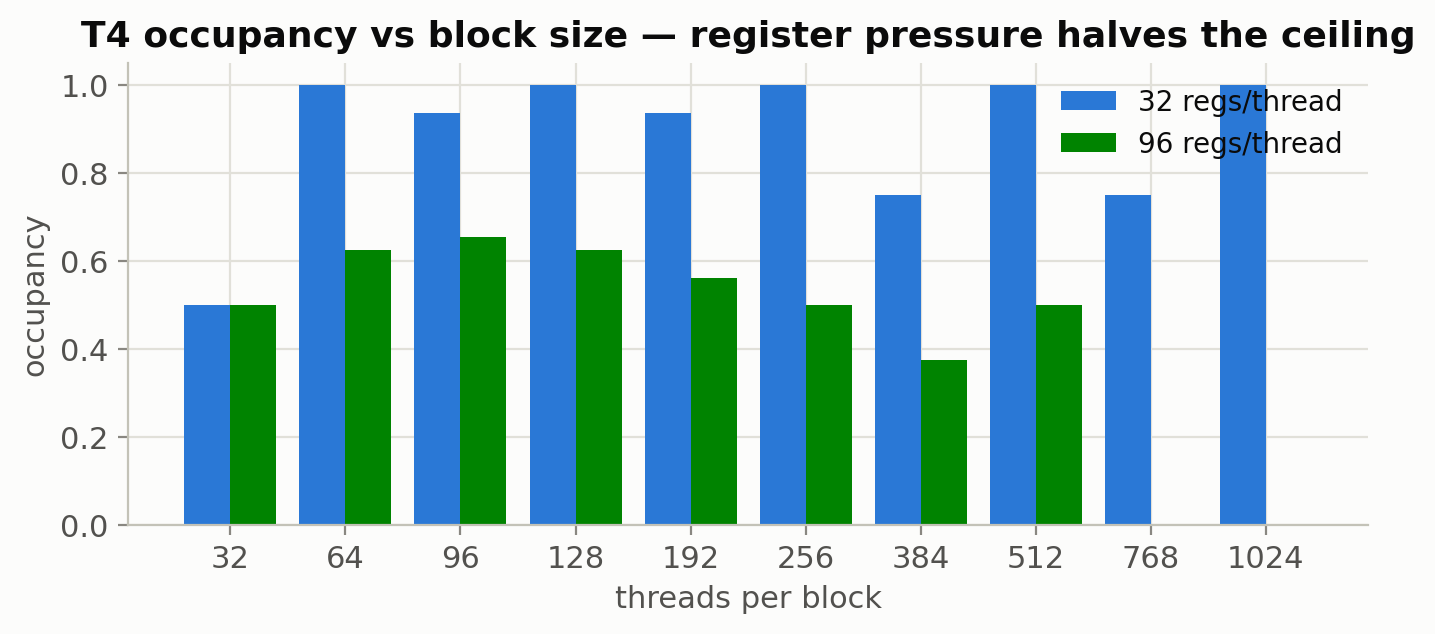

In [4]:
#| code-fold: true
#| code-summary: "Show plotting code"
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
for regs, offset in [(32, -0.2), (96, 0.2)]:
    sweep = occupancy_sweep(T4, regs_per_thread=regs)
    xs = np.arange(len(sweep))
    ax.bar(xs + offset, [o.occupancy for o in sweep], width=0.4, label=f'{regs} regs/thread')
ax.set_xticks(np.arange(len(sweep)), [str(o.threads_per_block) for o in sweep])
ax.set_xlabel('threads per block')
ax.set_ylabel('occupancy')
ax.set_title('T4 occupancy vs block size — register pressure halves the ceiling')
ax.legend()
plt.show()

Note 96-thread blocks: 93.75% with *zero* resource pressure — 3 warps per block simply
doesn't divide 32 slots. And at 96 registers/thread the ceiling halves everywhere: one extra
register per thread can evict a whole block.

## 2. A first timed run

`simulate()` runs the kernel functionally (correctness + access log), then replays it through
the machine model. Since Python kernels have no register allocator, you state what the real
kernel would use (`nvcc --ptxas-options=-v` prints it; 32 is a typical default).

In [5]:
from ai_playground.gpusim import kernel, simulate

@kernel
def copy(ctx, src, dst):
    i = ctx.grid(1)
    dst[i] = src[i]

n = 1024 * 32
src, dst = np.zeros(n, dtype=np.float32), np.zeros(n, dtype=np.float32)
trace = simulate(copy, 1024, 32, (src, dst))
trace.summary()

{'spec': 'T4',
 'total_cycles': 2062.1,
 'occupancy': 0.5,
 'occupancy_limiter': 'blocks',
 'dram_bytes': 262144,
 'achieved_GBps': 202.1,
 'peak_GBps': 320.0,
 'warp_cycles_by_state': {'exec': 8192.0, 'stall_mem': 1051751.8}}

Read it like a profiler: ~63% of peak bandwidth achieved (real T4s land in the same
range for plain copies), warp-cycles utterly dominated by `stall_mem` — a copy does no math —
and occupancy capped at 50% because 32-thread blocks hit the 16-block slot limit first.

## 3. Latency hiding, watched happening

The waterfall shows one SM's resident warps over time. Same kernel, same data — the only
change is shared-memory pressure dropping residency from 4 blocks/SM to 1:

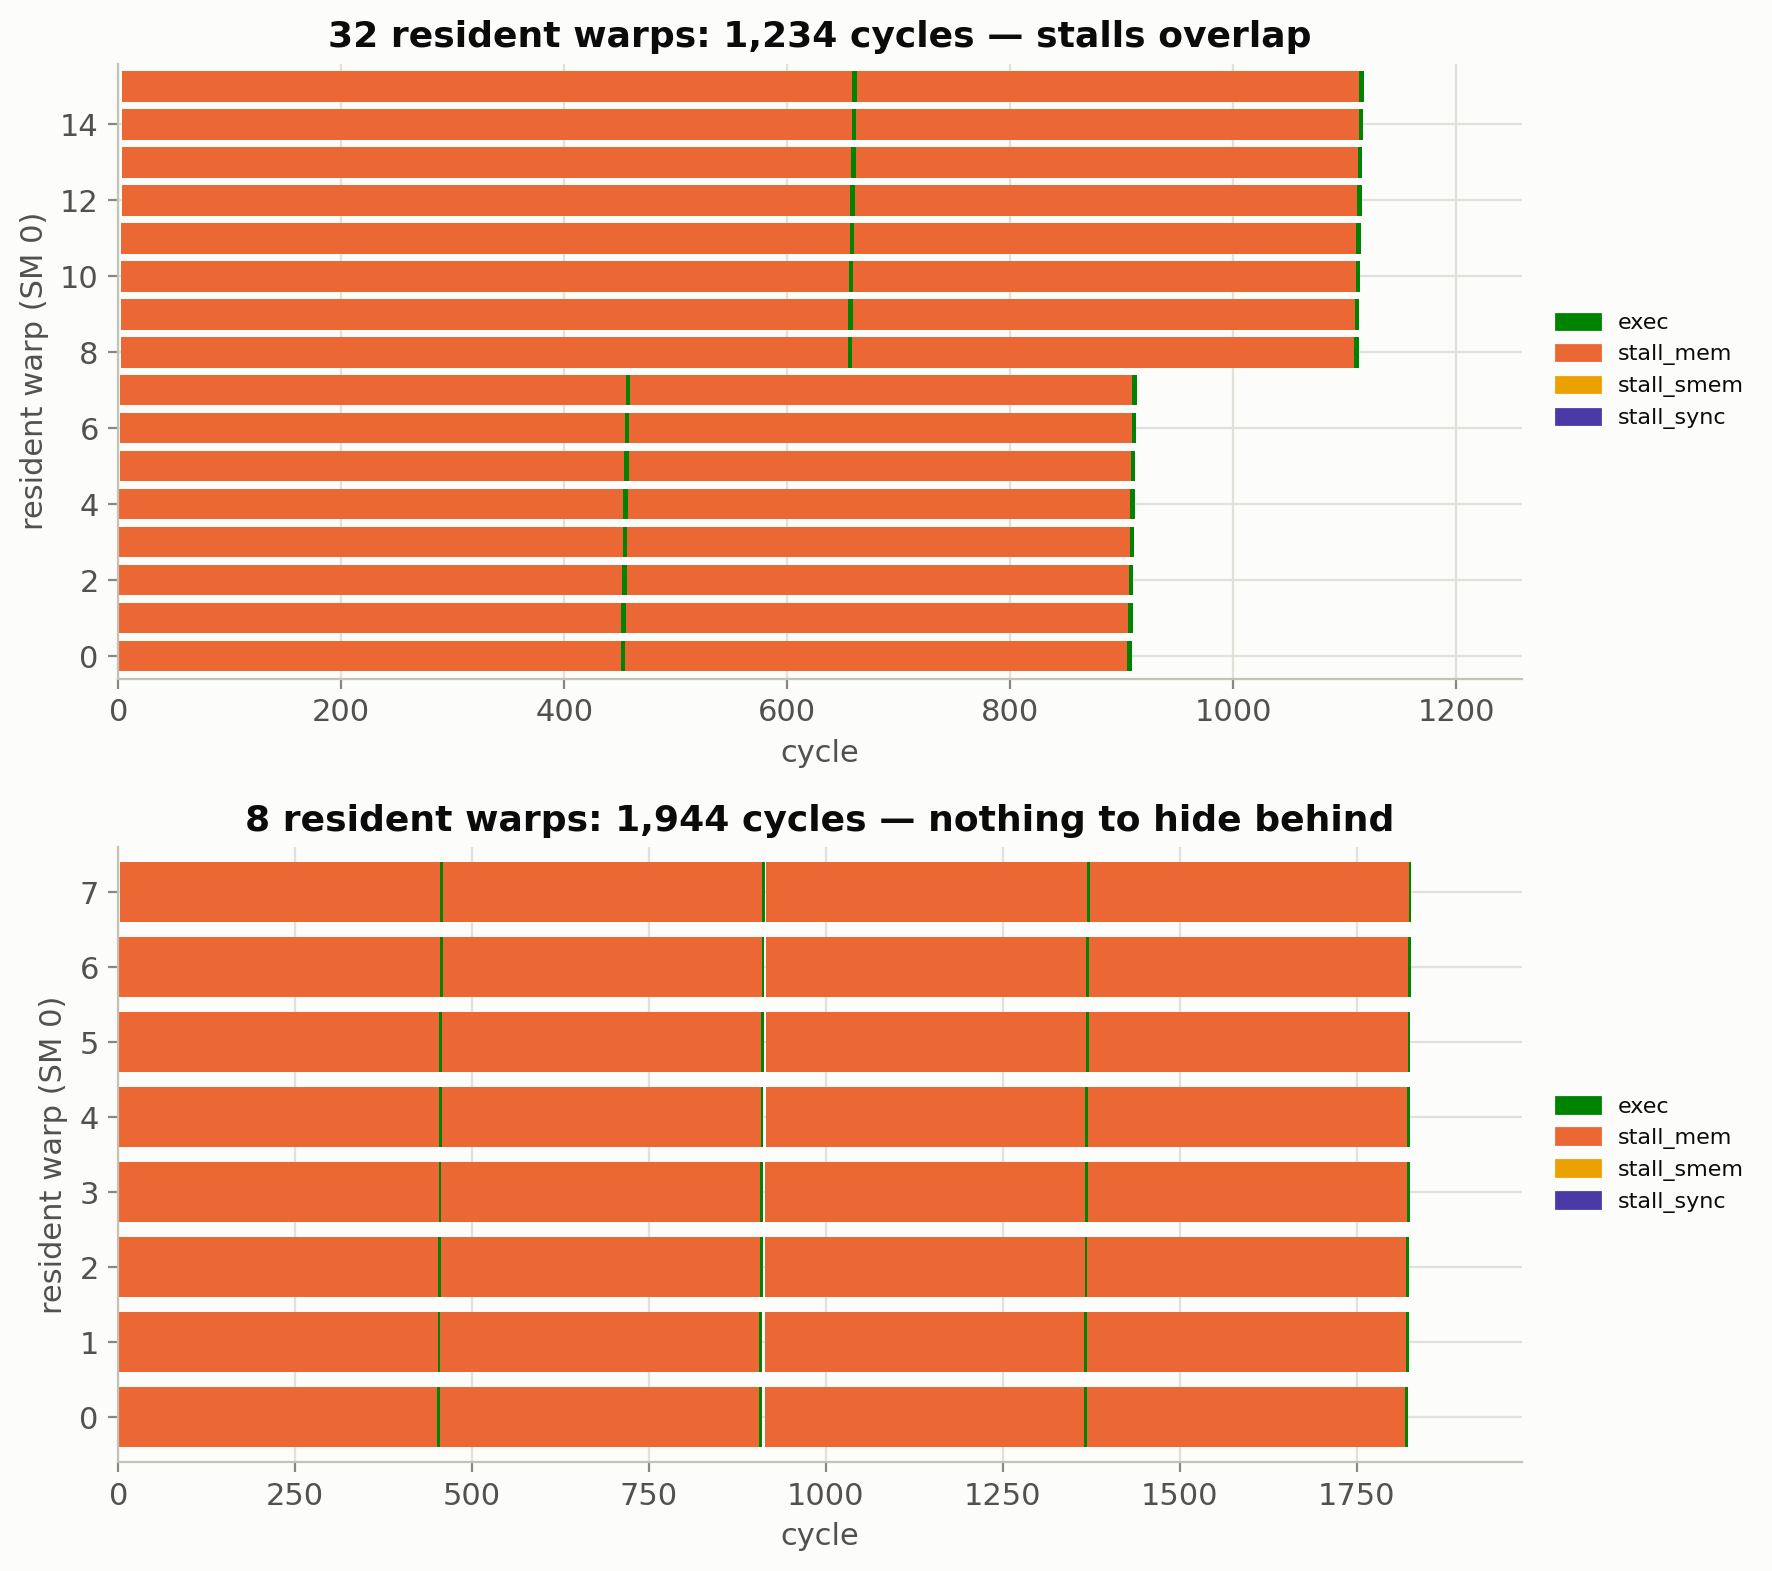

occupancy 100% -> 25%: 1.6x slower


In [6]:
#| code-fold: true
#| code-summary: "Show plotting code"
from ai_playground.gpusim import plot_waterfall

src, dst = np.zeros(64 * 256, dtype=np.float32), np.zeros(64 * 256, dtype=np.float32)
t_full = simulate(copy, 64, 256, (src, dst))
t_starved = simulate(copy, 64, 256, (src, dst), smem_per_block=48 * 1024)

fig, axes = plt.subplots(2, 1, figsize=(9, 8))
plot_waterfall(t_full, sm=0, ax=axes[0])
axes[0].set_title(f'{t_full.occupancy.warps_per_sm} resident warps: {t_full.total_cycles:,.0f} cycles — stalls overlap')
plot_waterfall(t_starved, sm=0, ax=axes[1])
axes[1].set_title(f'{t_starved.occupancy.warps_per_sm} resident warps: {t_starved.total_cycles:,.0f} cycles — nothing to hide behind')
plt.tight_layout()
plt.show()
print(f'occupancy {t_full.occupancy.occupancy:.0%} -> {t_starved.occupancy.occupancy:.0%}: '
      f'{t_starved.total_cycles / t_full.total_cycles:.1f}x slower')

Nobody told the model that occupancy hides latency — it has warps, stalls, and
schedulers, and the effect falls out. That is takeaway #5 of
[CUDA Basics](01_cuda_basics.ipynb), now as a picture.

## 4. The bandwidth wall, with a time axis

The [SIMT chapter](01b_simt_simulator.ipynb) counted 32x transactions for strided access.
Here's what those transactions *cost* once enough data is in flight to saturate the pipe:

In [7]:
@kernel
def copy_strided(ctx, src, dst):
    i = ctx.grid(1)
    dst[i] = src[32 * i]

big = np.zeros(32 * n, dtype=np.float32)
t_contig = simulate(copy, 1024, 32, (src := np.zeros(n, np.float32), np.zeros(n, np.float32)))
t_strided = simulate(copy_strided, 1024, 32, (big, np.zeros(n, np.float32)))

for name, t in [('contiguous', t_contig), ('strided', t_strided)]:
    s = t.summary()
    print(f'{name:11s}: {s["total_cycles"]:>9,.0f} cycles, '
          f'{s["dram_bytes"] / 1e6:5.1f} MB moved, {s["achieved_GBps"]:5.1f} GB/s achieved')
print(f'strided / contiguous: {t_strided.total_cycles / t_contig.total_cycles:.1f}x slower')

contiguous :     2,062 cycles,   0.3 MB moved, 202.1 GB/s achieved
strided    :    22,204 cycles,   4.3 MB moved, 309.7 GB/s achieved
strided / contiguous: 10.8x slower


Note the strided run's *achieved* bandwidth: the pipe is saturated — with garbage.
128 bytes cross the bus for every 4 useful ones. At small sizes this penalty mostly hides
behind latency; at scale it is the wall. (Compare the real-hardware measurement in
[CUDA Basics §7](01_cuda_basics.ipynb).)

## 5. The die: block waves across 40 SMs

2,048 blocks, 640 resident at a time (16 block slots x 40 SMs) — the rest wave in as blocks
retire. Green = executing, orange = stalled on DRAM, gray = empty slot; the right bar is the
DRAM pipe gauge. Press play:

In [8]:
#| code-fold: true
#| code-summary: "Show animation code"
from IPython.display import HTML
from ai_playground.gpusim import animate_floorplan

n_anim = 2048 * 32
big_src = np.zeros(n_anim, dtype=np.float32)
t_die = simulate(copy, 2048, 32, (big_src, np.zeros(n_anim, dtype=np.float32)))
anim = animate_floorplan(t_die, frames=36)
HTML(anim.to_jshtml(default_mode='once'))

A copy kernel keeps the die orange — memory-bound by construction, exactly what §2's
summary said in numbers. A compute-heavy kernel would run green with an idle gauge.

## 6. Take a trace to a real profiler UI

Every trace exports to Chrome trace format — SMs as processes, warp slots as threads, one
timestamp unit per cycle. Drop the file onto [ui.perfetto.dev](https://ui.perfetto.dev) (or
`chrome://tracing`) for pro-grade interactive scrubbing — the same viewer the repo's PyTorch
profiler wrapper targets:

In [9]:
import tempfile, os
path = os.path.join(tempfile.gettempdir(), 't4_copy_trace.json')
t_contig.to_chrome_json(path)
print(f'wrote {path} ({os.path.getsize(path) / 1e3:.0f} kB) — open it at https://ui.perfetto.dev')

wrote /var/folders/gm/lny259x17rjchmw201s4sfh80000gn/T/t4_copy_trace.json (600 kB) — open it at https://ui.perfetto.dev


## 7. Validate against the real card (Colab)

The spec's standing checklist ([docs/VIRTUAL_GPU_SPEC.md](https://github.com/ggreg/ai_playground/blob/main/docs/VIRTUAL_GPU_SPEC.md)
§ Validation): hardware numbers via deviceQuery, then the trend experiments. These cells are
skipped without CUDA — open this notebook on Colab (badge at the top, T4 runtime) and run them.
Acceptance bar: **rank order preserved, ratios within ~2×** — a miss is shown, not hidden.

In [10]:
import torch

HAS_CUDA = torch.cuda.is_available()
if not HAS_CUDA:
    print('No CUDA GPU here — open on Colab (T4 runtime) to run the validation.')
else:
    p = torch.cuda.get_device_properties(0)
    checks = [
        ('name contains T4', 'T4' in p.name, p.name),
        ('SM count', p.multi_processor_count == T4.n_sm, p.multi_processor_count),
        ('DRAM >= 15 GB', p.total_memory > 15e9, f'{p.total_memory / 1e9:.1f} GB'),
        ('compute capability 7.5', (p.major, p.minor) == (7, 5), f'{p.major}.{p.minor}'),
    ]
    for label, ok, got in checks:
        print(f'{"OK " if ok else "MISMATCH"}  {label}: {got}')

No CUDA GPU here — open on Colab (T4 runtime) to run the validation.


In [11]:
#| code-fold: true
#| code-summary: "Real-T4 trend experiments (numba) — run on Colab"
if HAS_CUDA:
    import math
    import numpy as np
    from numba import cuda

    def gpu_ms(fn, *args, runs=20):
        fn(*args); cuda.synchronize()          # warmup + JIT
        start, end = cuda.event(), cuda.event()
        start.record()
        for _ in range(runs):
            fn(*args)
        end.record(); end.synchronize()
        return start.elapsed_time(end) / runs

    # --- trend 1: contiguous vs strided copy bandwidth ---
    @cuda.jit
    def nb_copy(src, dst):
        i = cuda.grid(1)
        if i < dst.size:
            dst[i] = src[i]

    @cuda.jit
    def nb_copy_strided(src, dst):
        i = cuda.grid(1)
        if i < dst.size:
            dst[i] = src[32 * i]

    n = 1 << 24
    d_src = cuda.to_device(np.zeros(32 * n, np.float32))
    d_dst = cuda.device_array(n, np.float32)
    blocks = math.ceil(n / 256)
    ms_c = gpu_ms(lambda: nb_copy[blocks, 256](d_src, d_dst))
    ms_s = gpu_ms(lambda: nb_copy_strided[blocks, 256](d_src, d_dst))
    real_stride_ratio = ms_s / ms_c

    # --- simulator prediction for the same shape of experiment ---
    sim_c = simulate(copy, 1024, 32, (np.zeros(1024 * 32, np.float32),
                                      np.zeros(1024 * 32, np.float32)))
    sim_s = simulate(copy_strided, 1024, 32, (np.zeros(32 * 1024 * 32, np.float32),
                                              np.zeros(1024 * 32, np.float32)))
    sim_stride_ratio = sim_s.total_cycles / sim_c.total_cycles

    print(f'strided/contiguous slowdown:  real T4 {real_stride_ratio:5.1f}x   '
          f'virtual T4 {sim_stride_ratio:5.1f}x   '
          f'{"PASS" if 0.5 < sim_stride_ratio / real_stride_ratio < 2 else "MISS (explain!)"}')

    # --- trend 2: achieved bandwidth on the contiguous copy ---
    real_gbps = 2 * n * 4 / (ms_c * 1e-3) / 1e9
    print(f'contiguous copy bandwidth:    real T4 {real_gbps:5.0f} GB/s  '
          f'virtual T4 {sim_c.achieved_bandwidth / 1e9:5.0f} GB/s   '
          f'(theoretical peak {T4.dram_bandwidth / 1e9:.0f})')
else:
    print('skipped — no CUDA')

skipped — no CUDA


Record the numbers back into the spec doc when you run this — that closes the Phase-1/2
verification tasks. If a ratio misses the 2× bar, the interesting work is explaining *which
refusal* (caches? DRAM row effects?) accounts for the gap.

## 🏗️ Project milestone M11 — predict your decode step

::: {.callout-note appearance="simple"}
One decode step of your model at batch 8 moves roughly `weight_bytes + 8 x kv_bytes(t)` from
DRAM. Simulate that traffic on the virtual T4 (a copy kernel sized to those bytes is a fair
proxy for a memory-bound step), read predicted cycles and achieved GB/s from the trace
summary, and convert to a predicted tokens/sec. Record it in `metrics.json['m11_predicted']`
— and if you're on Colab, run the §7 validation cells and record the real bandwidth beside it.

**Accept when**: predicted decode tokens/sec is in `metrics.json` with the assumptions noted.
Part of [The Project: Serve Your Own LLM](../../docs/PROJECT.md).
:::

## Key Takeaways

1. **Occupancy is a min over four caps** — warp slots, block slots, registers (with 256/warp
   allocation granularity), shared memory — and knowing *which* cap binds tells you what to fix.
2. **Latency hiding emerges from having enough warps.** 32 resident warps absorb a ~450-cycle
   stall; 4 leave the SM idle — the model produces this, it doesn't assert it.
3. **Coalescing is a bandwidth-pipe tax.** Strided access saturates DRAM with mostly-wasted
   bytes; the gauge shows a full pipe and a slow kernel simultaneously.
4. **Blocks arrive in waves** sized by occupancy x SM count; the die animation makes grid-size
   effects (tail waves, partial last wave) visible.
5. **Cycle-approximate means ratios, not milliseconds.** No caches, no ILP, no DRAM row
   effects — see the spec's Refusals. Validate trends against the real T4 via the Colab badge;
   the spec's validation table is the standing checklist.

### What to read next

- [`02_sgemm_optimization.ipynb`](02_sgemm_optimization.ipynb) — real CUDA on real hardware,
  where these effects become nanoseconds instead of colored pixels.
- The engine: `src/ai_playground/gpusim/timing.py` (~200 lines) — small enough to read, and
  modifying it (add an L2? model dual-issue?) is a great exercise.
- [docs/VIRTUAL_GPU_SPEC.md](https://github.com/ggreg/ai_playground/blob/main/docs/VIRTUAL_GPU_SPEC.md)
  — the design contract, refusals, and what's still unvalidated.
